<a href="https://colab.research.google.com/github/rehunter3502026-max/global-economic-intelligence-dashboard/blob/main/Global_Economic_Intelligence_Dashboard1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================
# IMPORT LIBRARIES
# ==========================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

import warnings
warnings.filterwarnings("ignore")

In [2]:
# ==========================
# LOAD DATASET
# ==========================

df = pd.read_csv("global_economic_intelligence_dataset.csv")

print(df.shape)

df.head()

(4000, 11)


,country,year,population,gdp_usd,gdp_per_capita_usd,inflation_rate,unemployment_rate,life_expectancy,hdi,co2_tonnes_per_capita,economic_growth_rate
0,USA,2015,668000000,14209696000000,21272,4.13,2.77,80.9,0.589,11.86,7.92
1,USA,2015,444000000,2847816000000,6414,0.12,8.69,67.5,0.776,1.65,3.79
2,USA,2015,462000000,38880534000000,84157,7.16,17.16,75.3,0.713,19.54,-2.44
3,USA,2015,277000000,10930143000000,39459,4.45,10.65,75.1,0.780,13.80,-1.76
4,USA,2015,1174000000,30669576000000,26124,3.84,10.76,63.4,0.574,4.52,5.16


In [3]:
# ==========================
# DATASET INFORMATION
# ==========================

print(df.info())

print("\n")

print(df.describe())

print("\nMissing Values\n")

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   country                4000 non-null   object 
 1   year                   4000 non-null   int64  
 2   population             4000 non-null   int64  
 3   gdp_usd                4000 non-null   int64  
 4   gdp_per_capita_usd     4000 non-null   int64  
 5   inflation_rate         4000 non-null   float64
 6   unemployment_rate      4000 non-null   float64
 7   life_expectancy        4000 non-null   float64
 8   hdi                    4000 non-null   float64
 9   co2_tonnes_per_capita  4000 non-null   float64
 10  economic_growth_rate   4000 non-null   float64
dtypes: float64(6), int64(4), object(1)
memory usage: 343.9+ KB
None


             year    population       gdp_usd  gdp_per_capita_usd  \
count  4000.00000  4.000000e+03  4.000000e+03          4000.00000   
mean   2

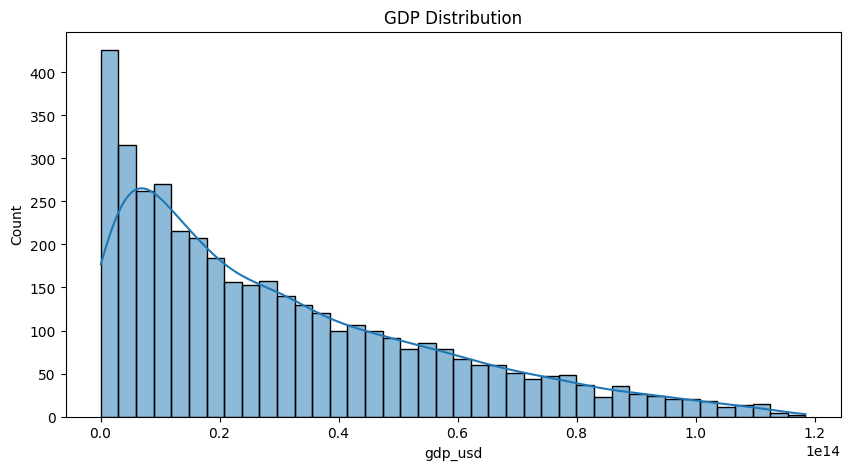

In [4]:
# ==========================
# GDP DISTRIBUTION
# ==========================

plt.figure(figsize=(10,5))

sns.histplot(
    df["gdp_usd"],
    bins=40,
    kde=True
)

plt.title("GDP Distribution")

plt.show()

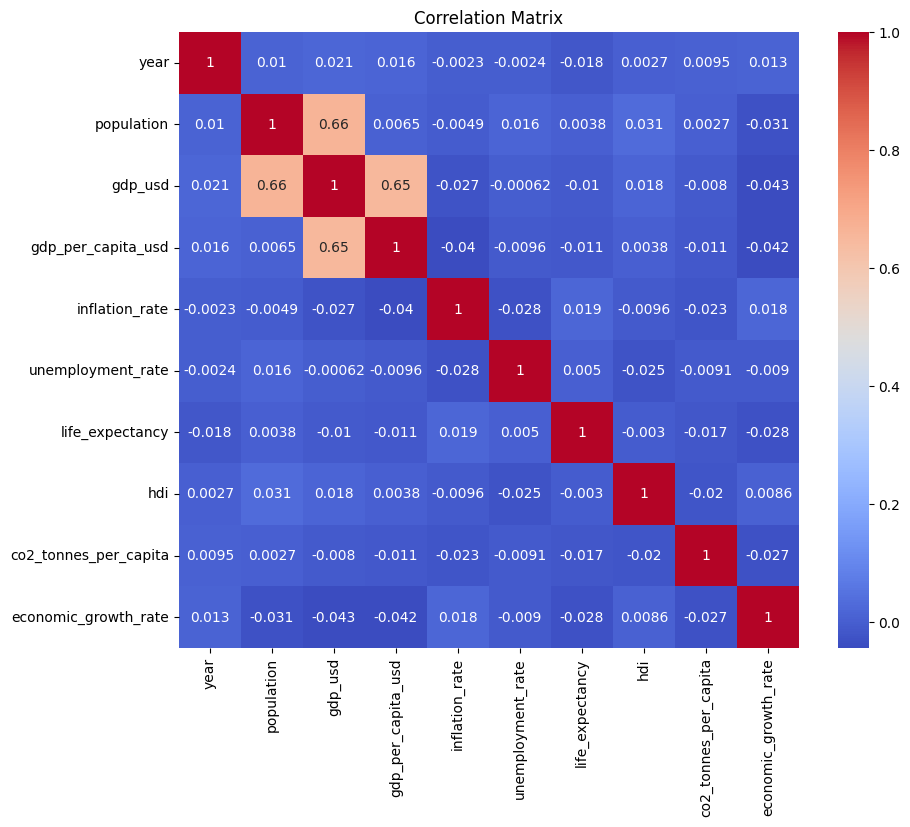

In [5]:
# ==========================
# CORRELATION HEATMAP
# ==========================

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()


In [6]:
# ==========================
# FEATURES & TARGET
# ==========================

X = df.drop("economic_growth_rate", axis=1)
y = df["economic_growth_rate"]

print("Feature Shape:", X.shape)
print("Target Shape :", y.shape)

Feature Shape: (4000, 10)
Target Shape : (4000,)


In [7]:
# ==========================
# PREPROCESSING
# ==========================

categorical_columns = ["country"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        )
    ],
    remainder="passthrough"
)

print("Preprocessor Created Successfully!")

Preprocessor Created Successfully!


In [8]:
# ==========================
# TRAIN TEST SPLIT
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 3200
Testing Samples  : 800


In [9]:
# ==========================
# RANDOM FOREST MODEL
# ==========================

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Model Trained Successfully!")

Model Trained Successfully!


In [10]:
# ==========================
# MODEL EVALUATION
# ==========================

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

MAE : 3.0044
RMSE: 3.4817
R²  : -0.0233


In [11]:
# ==========================
# FEATURE IMPORTANCE
# ==========================

feature_names = model.named_steps["preprocessor"].get_feature_names_out()

importance = model.named_steps["regressor"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
24,remainder__inflation_rate,0.109624
28,remainder__co2_tonnes_per_capita,0.109373
25,remainder__unemployment_rate,0.109343
26,remainder__life_expectancy,0.104004
27,remainder__hdi,0.103977
23,remainder__gdp_per_capita_usd,0.102212
21,remainder__population,0.098092
22,remainder__gdp_usd,0.093762
20,remainder__year,0.055110
18,cat__country_UK,0.007270


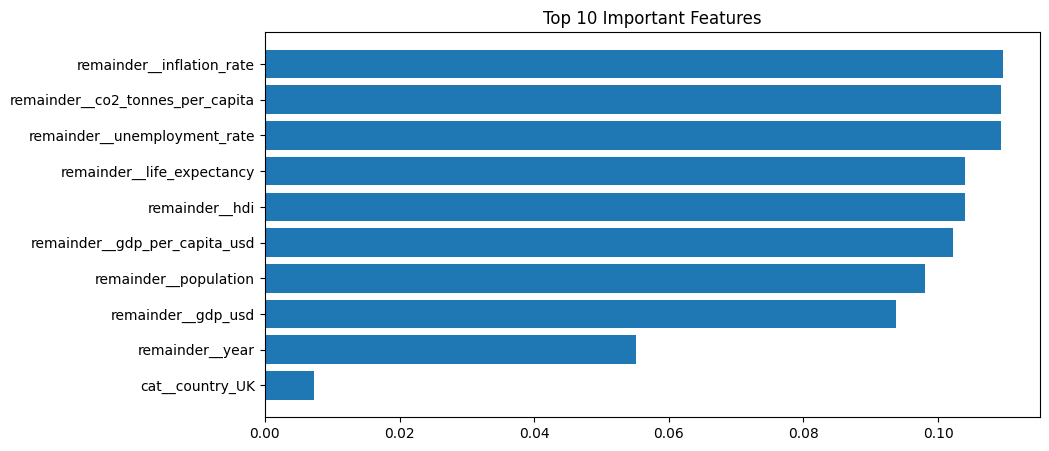

In [12]:
# ==========================
# FEATURE IMPORTANCE PLOT
# ==========================

top_features = importance_df.head(10)

plt.figure(figsize=(10,5))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")

plt.show()

In [13]:
# ==========================
# SAMPLE PREDICTION
# ==========================

sample = pd.DataFrame([{
    "country": "India",
    "year": 2025,
    "population": 1450000000,
    "gdp_usd": 4200000000000,
    "gdp_per_capita_usd": 2900,
    "inflation_rate": 5.2,
    "unemployment_rate": 6.5,
    "life_expectancy": 70.5,
    "hdi": 0.69,
    "co2_tonnes_per_capita": 2.1
}])

prediction = model.predict(sample)

print(f"Predicted Economic Growth Rate: {prediction[0]:.2f}%")

Predicted Economic Growth Rate: 2.13%


In [14]:
# ==========================
# SAVE MODEL
# ==========================

joblib.dump(model, "global_economic_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [15]:
# ==========================
# LOAD MODEL
# ==========================

loaded_model = joblib.load("global_economic_model.pkl")

prediction = loaded_model.predict(sample)

print(f"Prediction from Loaded Model: {prediction[0]:.2f}%")

Prediction from Loaded Model: 2.13%
